# Bogus Basin Snow Depth

In [3]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import sys
from data_registry import datasets
from scipy.ndimage import uniform_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.interpolate import interp1d
from utils import mainutil
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.gam.api import GLMGam
from statsmodels.gam.api import BSplines

import warnings
warnings.filterwarnings("ignore")
# os.getcwd()
# os.chdir(r"C:\Users\ryanc\repo\Time-Series-Analysis-Project")
    

In [65]:
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true+1e-6 - pred) ** 2) / np.sum((true+1e-6 - np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)


## Plot and Exploratory Analysis

*Read data*

In [5]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])

snow_data['Date'] = pd.to_datetime(snow_data['Date'])
snow_data.set_index('Date',drop=True, inplace=True)

snow_daily = mainutil.to_ts(snow_data['Depth'], snow_data.index)


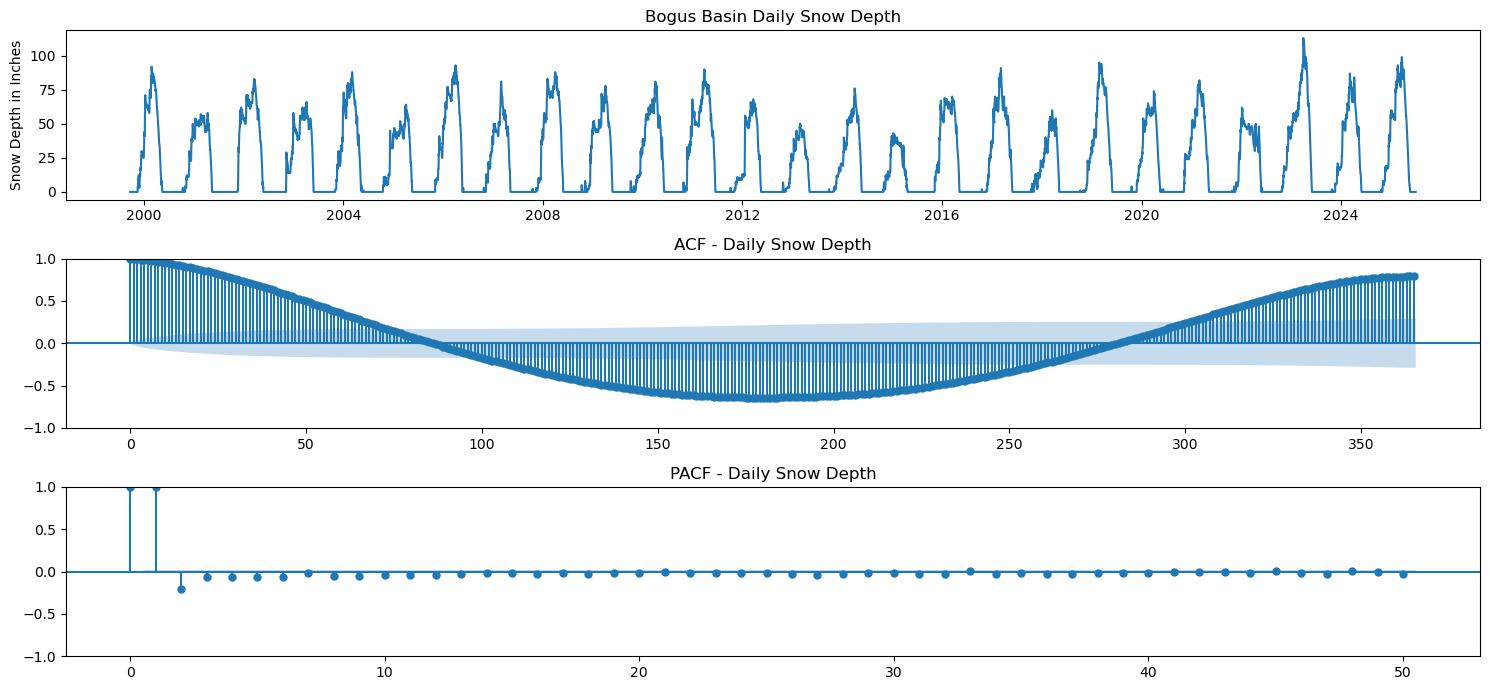

In [17]:
fig, axs = plt.subplots(3,1 ,figsize=(15,7))
axs[0].plot(snow_daily['ts'])
axs[0].set_title('Bogus Basin Daily Snow Depth')
axs[0].set_ylabel("Snow Depth in Inches")
plot_acf(snow_daily['ts'], lags = 365, ax = axs[1], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily['ts'], lags = 50, ax = axs[2], title = "PACF - Daily Snow Depth");

# axs[1].plot(snow_monthly['ts'], marker = '.', markersize = 5  )
# axs[1].set_title('Bogus Basin Monthly Average Snow Depth')
# axs[1].set_ylabel("Snow Depth in Inches")
fig.tight_layout()
fig.show()

The daily snow data exhibits a strong seasonal pattern with no clear discernable trend. A key feature of this data is the large periods of time with zero values during the warmer months.  While one approach could be to remove all the zero values, they are a key data point, as forecasting when snow begins and ends is a key part of this analysis.  Close attention will be paid to how successful the models are in capturing these zero points. 

## Modeling



Splitting data into training and testing data sets, with testing set for the last year's worth of data. Adding in categorical viariables at month, week, and day levels for seasonal analysis 

In [7]:
cutoff_date = '06/01/2024'

sd= snow_daily.copy()
sd['month'] = sd.index.month
sd['week'] = sd.index.isocalendar().week.astype('int')
sd['day'] = sd.index.dayofyear

sd_train = sd[sd.index<cutoff_date]
sd_test = sd[sd.index>=cutoff_date]

print(sd_train.tail())
print(sd_test.head())


            ts       pts  month  week  day
Date                                      
2024-05-27   4  0.957598      5    22  148
2024-05-28   2  0.957705      5    22  149
2024-05-29   1  0.957811      5    22  150
2024-05-30   0  0.957917      5    22  151
2024-05-31   0  0.958023      5    22  152
            ts       pts  month  week  day
Date                                      
2024-06-01   0  0.958130      6    22  153
2024-06-02   0  0.958236      6    22  154
2024-06-03   0  0.958342      6    23  155
2024-06-04   0  0.958448      6    23  156
2024-06-05   0  0.958555      6    23  157


### Trend Estimation Using Moving Average, Local Polynomial, and Splines

In [38]:
#Moving Average Trend
mavModel = uniform_filter1d(sd_train['ts'], size=len(sd_train['ts'])//2)
mavModel
mav_data = pd.Series(mavModel, index=sd_train.index)
sd_train['mav2'] = sd_train['ts'].rolling(window =180, center = True, min_periods=1).mean()

#Lowess Trend
localPolyModel = sm.nonparametric.lowess(endog=sd_train['ts'], exog=sd_train['pts'], is_sorted=True, frac=0.3)

## extrapolate local polynomial and Moving Average onto test data
f = interp1d(localPolyModel[:,0], localPolyModel[:,1], bounds_error=False, fill_value="extrapolate")
sd_test['LocalPoly_Trend'] = f(sd_test['pts'])
sd_test['MovingAvg_Trend'] = mav_data[-1]

# Splines Trend
gamModel = GLMGam.from_formula(
    formula='ts ~ 1', data=sd_train, alpha=100,
    family=sm.families.Gaussian(),
    smoother=BSplines(sd_train['pts'], df=500, degree=3)).fit()



localPolyData = pd.Series(localPolyModel[:,1], index=sd_train.index)
sd_train['MovingAvg_Trend'] = mav_data
sd_train['LocalPoly_Trend'] = localPolyData
sd_train['spline'] = gamModel.fittedvalues


Text(0.5, 1.0, 'Snow Depth Trend')

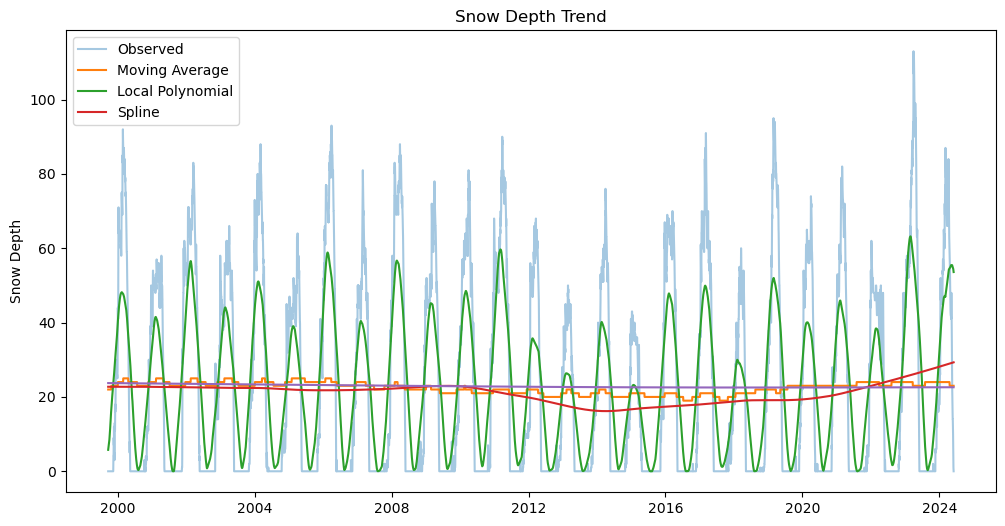

In [39]:
plt.figure(figsize = (12,6))
plt.plot(sd_train['ts'], alpha =.4)
plt.plot(sd_train['MovingAvg_Trend'])
plt.plot(sd_train['mav2'])
plt.plot(sd_train['LocalPoly_Trend'])
plt.plot(sd_train['spline'])

plt.legend(['Observed', 'Moving Average', 'Local Polynomial', 'Spline'])
plt.ylabel('Snow Depth')
plt.title("Snow Depth Trend")

To determine any trend in the data, a moving average, local polynomial using LOWESS, and splines regression were all used.  The moving average appears to capture some of the seasonal pattern in the data.  The splines regression shows no discernable trend, while the local polynomial shows a slight decrease from 2012 to 2016, and then an increase from 2016 till 2024. As the local polynomial appears to best capture the long term fluctuations in the daily snow levels, it will be used in further decomposition models. 

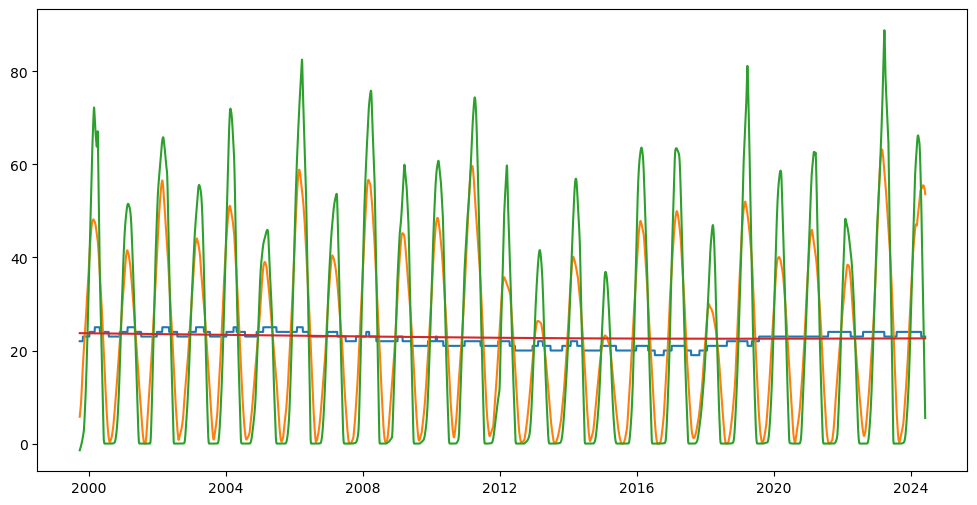

In [31]:
plt.figure(figsize = (12,6))

plt.plot(sd_train['MovingAvg_Trend'])
plt.plot(sd_train['mav2'])
plt.plot(sd_train['LocalPoly_Trend'])
plt.plot(sd_train['spline'])

### Seaonality Estimation

In [40]:
def generate_fourier_terms(time, period, K):

    fourier_terms = {}
    for k in range(1, K + 1):
        fourier_terms[f'sin_{k}'] = np.sin(2 * np.pi * k * time / period)
        fourier_terms[f'cos_{k}'] = np.cos(2 * np.pi * k * time / period)
    return pd.DataFrame(fourier_terms)


f_train = generate_fourier_terms(sd_train.index.dayofyear, 365, 3)
f_train =f_train.set_index(sd_train.index)
f_train


,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,
1999-09-23,-0.991114,-0.133015,0.263665,-0.964614,0.920971,0.389630
1999-09-24,-0.993257,-0.115935,0.230306,-0.973118,0.939856,0.341571
1999-09-25,-0.995105,-0.098820,0.196673,-0.980469,0.956235,0.292600
1999-09-26,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850
1999-09-27,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452
...,...,...,...,...,...,...
2024-05-27,0.559589,-0.828770,-0.927542,0.373720,0.977848,0.209315
2024-05-28,0.545240,-0.838280,-0.914128,0.405426,0.987349,0.158559
2024-05-29,0.530730,-0.847541,-0.899631,0.436651,0.994218,0.107381


In [41]:
sd_train =sd_train.join(f_train)


ValueError: columns overlap but no suffix specified: Index(['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3'], dtype='object')

In [43]:


sd_train['ts_sqrt'] = np.sqrt(sd_train['ts'])



seasonalmodel_LocalPoly_trend_Harmonic2 = smf.ols(formula = 'ts_sqrt~ sin_1 + cos_1+ +cos_2 +sin_2+ LocalPoly_Trend', data = sd_train).fit()
seasonalmodel_LocalPoly_trend_Harmonic3 = smf.ols(formula = 'ts_sqrt~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
easonalmodel_LocalPoly_trend_Harmonic3 = smf.ols(formula = 'ts_sqrt~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ mav2', data = sd_train).fit()
seasonal_model_WeeklyAnova_w_Poly = smf.ols(formula = 'ts_sqrt~C(week)+LocalPoly_Trend', data = sd_train).fit()
seasonal_model_MonthlyAnova_w_Poly = smf.ols(formula = 'ts_sqrt~C(month)+MovingAvg_Trend', data = sd_train).fit()


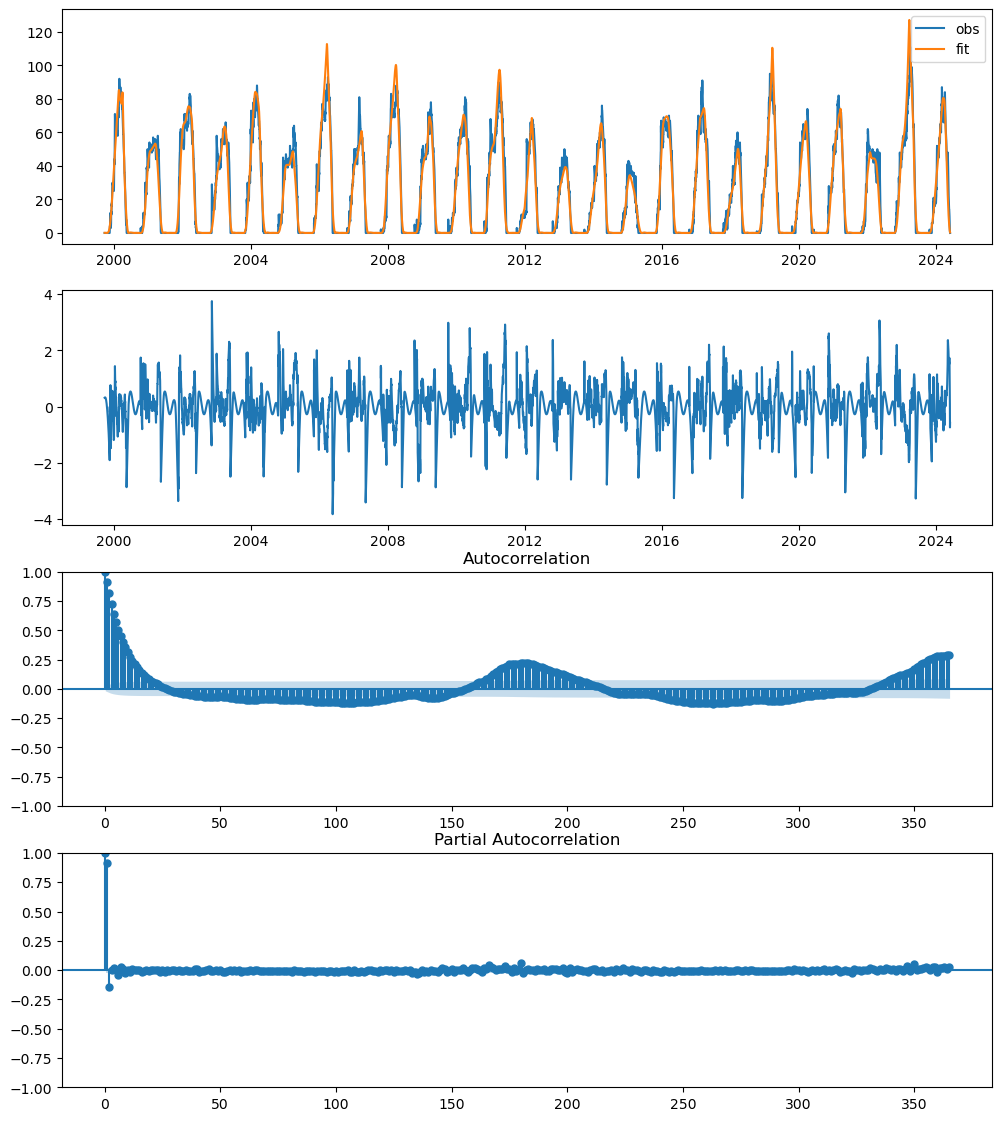

In [35]:
fig, axs = plt.subplots(4,1, figsize =(12,14) )
axs[0].plot(sd_train['ts'])
axs[0].plot(seasonalmodel_LocalPoly_trend_Harmonic3.fittedvalues**2)
#axs[0].plot(seasonalmodel_LocalPoly_trend_Harmonic2.fittedvalues**2)

axs[1].plot(seasonalmodel_LocalPoly_trend_Harmonic3.resid)
axs[0].legend(['obs', 'fit',])

plot_acf(seasonalmodel_LocalPoly_trend_Harmonic3.resid**2, lags = 365, ax = axs[2]);
plot_pacf(seasonalmodel_LocalPoly_trend_Harmonic3.resid**2, lags = 365, ax = axs[3]);
#plt.plot(seasonalmodel.params)

Prepping test data for forecasting

In [44]:
f_test = generate_fourier_terms(sd_test.index.dayofyear, 365, 3)
f_test = f_test.set_index(sd_test.index)
sd_test = sd_test.join(f_test)

ValueError: columns overlap but no suffix specified: Index(['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3'], dtype='object')

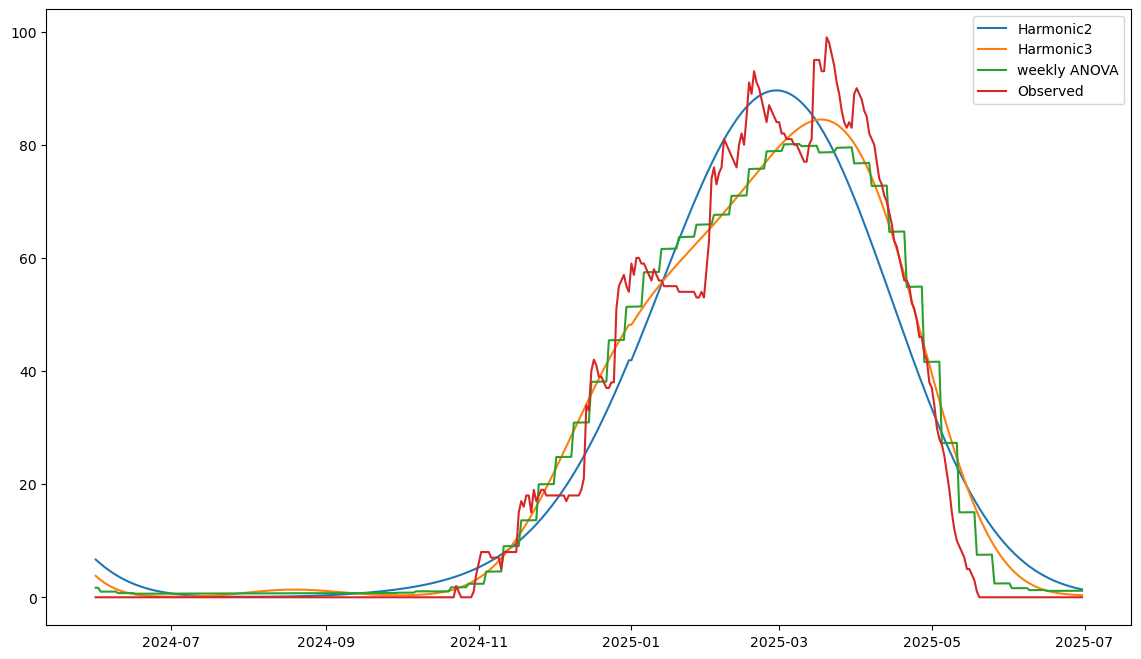

In [45]:

sd_test['ts_sqrt'] = np.sqrt(sd_test['ts'])
sd_test['ts_log'] = np.log(sd_test['ts']+1)
sd_test['mav2'] = sd_test['ts'].rolling(window =180, center = True, min_periods=1).mean()


plt.figure( figsize = (14,8))
#plt.plot(seasonalmodel_LocalPoly_trend_myf.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test)**2)
#plt.plot(seasonalmodel_no_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_LocalPoly_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_MA_trend.predict(exog=sd_test)**2)
plt.plot(seasonal_model_WeeklyAnova_w_Poly.predict(exog=sd_test)**2)
# plt.plot(seasonal_model_DailyAnova_w_Poly.predict(exog=sd_test)**2)
plt.plot(sd_test['ts'])
plt.legend(['Harmonic2', 'Harmonic3', "weekly ANOVA", 'Observed'])

In [46]:
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test)**2, 'local poly harmonic 2' )
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test)**2, 'local poly harmonic 3' )
evaluate_performance(sd_test['ts'],seasonal_model_WeeklyAnova_w_Poly.predict(exog = sd_test)**2, 'weekly anova' )

=== local poly harmonic 2 Performance ===
MSPE: 57.9606
MAE:  5.3526
MAPE: 1186911.0808
PM:   0.0529
----------------------------------------
=== local poly harmonic 3 Performance ===
MSPE: 32.4742
MAE:  3.8341
MAPE: 744902.9802
PM:   0.0296
----------------------------------------
=== weekly anova Performance ===
MSPE: 34.0933
MAE:  3.8745
MAPE: 560513.6624
PM:   0.0311
----------------------------------------


In [47]:
maxp=4
maxd=2
maxq=4

best_bic = np.inf
selected_orders = (0,0,0)

for p in range(maxp+1):
    for q in range(maxq+1):
        for d in range(maxd):
            orders = (p,d,q)
            model = sm.tsa.statespace.SARIMAX(
                sd_train['ts_sqrt'], 
                exog = f_train,
                order=orders                   
                        )

    results = model.fit()
    bic = results.bic
    if bic < best_bic:
        best_bic = bic
        selected_orders = orders

print(selected_orders, bic)

(3, 1, 4) -424.0466388671615


In [48]:
arima_fourier_model =sm.tsa.statespace.SARIMAX(
                sd_train['ts_sqrt'], 
                exog = f_train,
                order=selected_orders ).fit()
print(arima_fourier_model.summary())


                               SARIMAX Results                                
Dep. Variable:                ts_sqrt   No. Observations:                 9016
Model:               SARIMAX(3, 1, 4)   Log Likelihood                 299.373
Date:                Sat, 25 Apr 2026   AIC                           -570.745
Time:                        16:11:46   BIC                           -471.252
Sample:                             0   HQIC                          -536.893
                               - 9016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1          3.4586      0.234     14.798      0.000       3.000       3.917
cos_1          2.7256      0.151     18.092      0.000       2.430       3.021
sin_2          0.6842      0.123      5.581      0.0

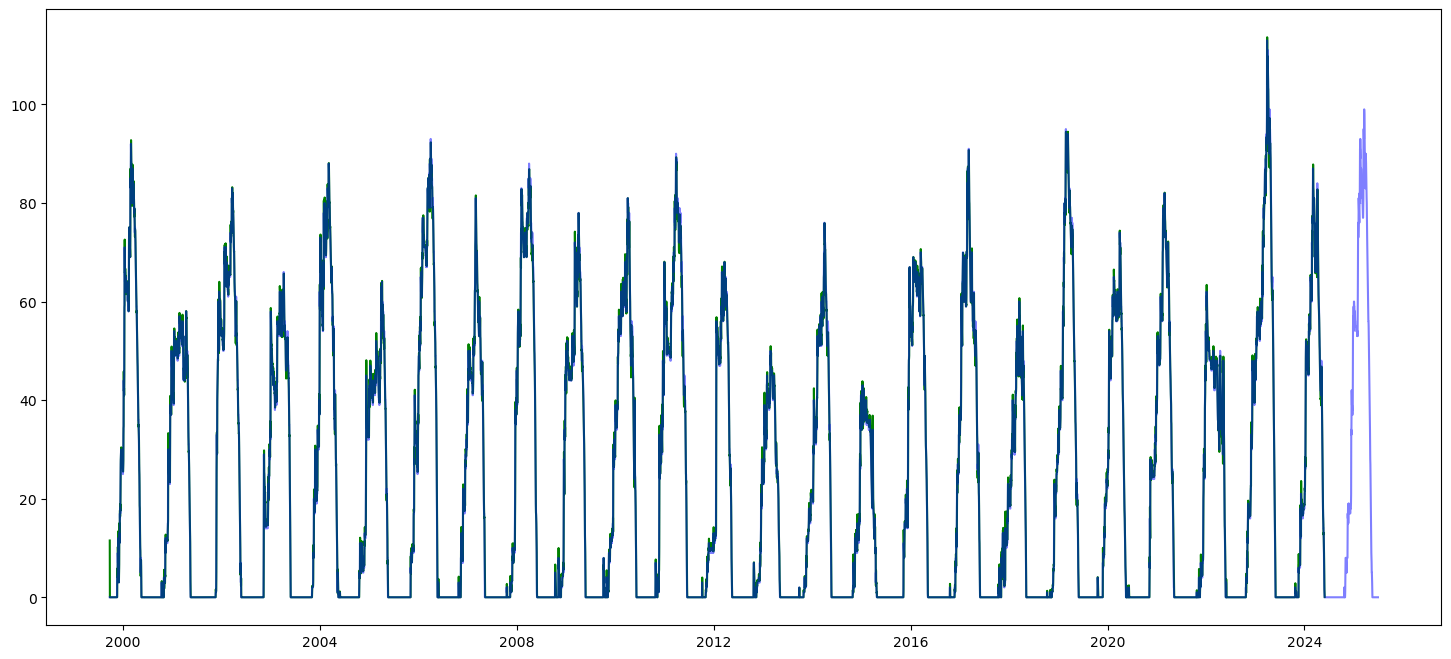

In [50]:
plt.figure(figsize= (18,8))
plt.plot(arima_fourier_model.fittedvalues**2, color = 'green')
plt.plot(sd['ts'], alpha=.5 ,color = 'blue')
forecast= arima_fourier_model.forecast(steps = 395, exog = f_test)


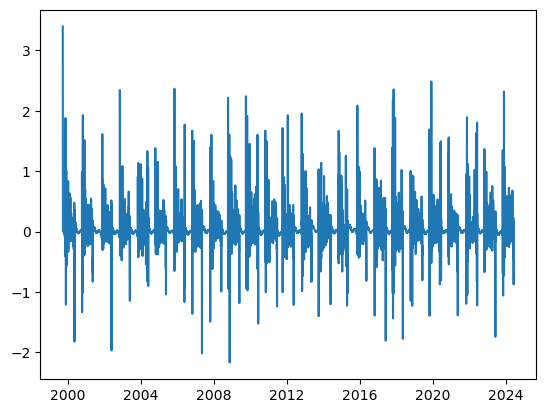

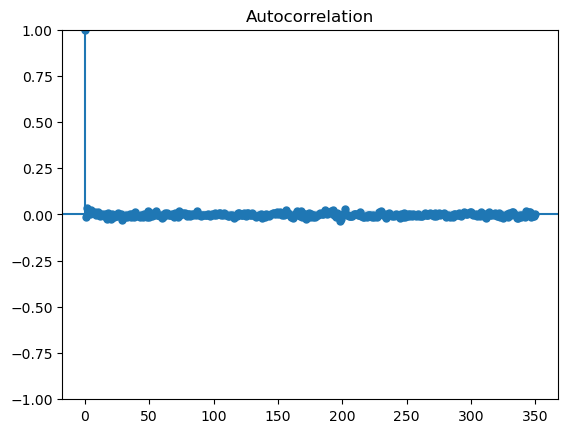

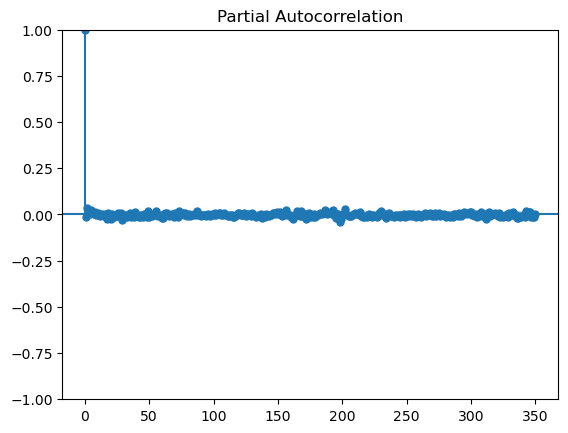

In [51]:
plt.plot(arima_fourier_model.resid)
plot_acf(arima_fourier_model.resid, lags = 350);
plot_pacf(arima_fourier_model.resid, lags = 350);

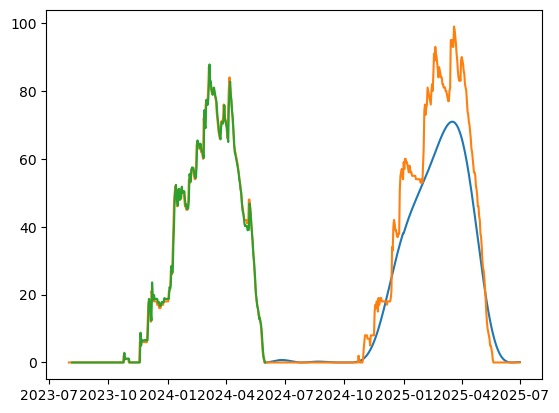

In [54]:
plt.plot(sd_test.index, forecast**2 )
plt.plot(sd['ts'][-700:])
plt.plot(arima_fourier_model.fittedvalues[-300:]**2)


In [57]:
evaluate_performance(sd_test['ts_sqrt'], forecast, 'Arima' )

=== Arima Performance ===
MSPE: 0.7567
MAE:  0.7056
MAPE: nan
PM:   0.0000
----------------------------------------


In [578]:
    
test = pd.concat([sd_train.tail(), sd_test.head()])
print(test)

            ts       pts  month  week  day       mav2  MovingAvg_Trend  \
Date                                                                     
2024-05-27   4  0.957598      5    22  148  45.518717               23   
2024-05-28   2  0.957705      5    22  149  45.731183               23   
2024-05-29   1  0.957811      5    22  150  45.945946               23   
2024-05-30   0  0.957917      5    22  151  46.163043               23   
2024-05-31   0  0.958023      5    22  152  46.382514               23   
2024-06-01   0  0.958130      6    22  153        NaN               23   
2024-06-02   0  0.958236      6    22  154        NaN               23   
2024-06-03   0  0.958342      6    23  155        NaN               23   
2024-06-04   0  0.958448      6    23  156        NaN               23   
2024-06-05   0  0.958555      6    23  157        NaN               23   

            LocalPoly_Trend     spline     sin_1     cos_1     sin_2  \
Date                                   

In [58]:
sd_train_roll = sd_train.copy()
sd_train_roll[7:14]

,ts,pts,month,week,day,mav2,MovingAvg_Trend,LocalPoly_Trend,spline,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,ts_sqrt
Date,,,,,,,,,,,,,,,,
1999-09-30,0,0.000744,9,39,273,7.268041,22,22.740338,23.727642,-0.999917,-0.012910,0.025818,-0.999667,0.999250,0.038722,0.0
1999-10-01,0,0.000850,10,39,274,7.448980,22,22.740358,23.727402,-0.999991,0.004304,-0.008607,-0.999963,0.999917,-0.012910,0.0
1999-10-02,0,0.000956,10,39,275,7.626263,22,22.740378,23.727162,-0.999769,0.021516,-0.043022,-0.999074,0.997917,-0.064508,0.0
1999-10-03,0,0.001063,10,39,276,7.810000,22,22.740398,23.726922,-0.999250,0.038722,-0.077386,-0.997001,0.993257,-0.115935,0.0
1999-10-04,0,0.001169,10,40,277,8.000000,22,22.740417,23.726681,-0.998435,0.055917,-0.111659,-0.993747,0.985948,-0.167052,0.0
1999-10-05,0,0.001275,10,40,278,8.245098,22,22.740436,23.726441,-0.997325,0.073095,-0.145799,-0.989314,0.976011,-0.217723,0.0
1999-10-06,0,0.001382,10,40,279,8.495146,22,22.740454,23.726201,-0.995919,0.090252,-0.179767,-0.983709,0.963471,-0.267814,0.0


In [60]:
forecast_period = 7
number_of_runs = len(sd_test)//forecast_period
results = []
for r in range(1,number_of_runs):
    if r == 1:
        train_rolling = sd_train.copy()
        test_rolling = sd_test.copy()[:forecast_period]
    else: 
        train_rolling = pd.concat([train_rolling, test_rolling])
        test_rolling = sd_test.copy()[forecast_period*(r-1):forecast_period*r]
    f_train = train_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']]
    f_test = test_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']]
    
    if len(test_rolling) == forecast_period:  forecast_period = forecast_period
    else: forecast_period = len(test_rolling)
    model = sm.tsa.statespace.SARIMAX(
                train_rolling['ts_sqrt'], 
                exog = f_train,
                order=selected_orders ).fit()
    forecast = model.forecast(steps = forecast_period, exog = f_test)
    forecast = forecast.set_axis(test_rolling.index)
     
    results.append(forecast)
full_forecast = pd.concat(results)




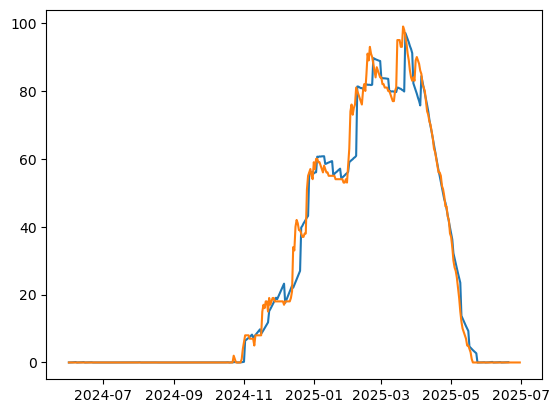

In [62]:
plt.plot(full_forecast**2)
plt.plot(sd_test['ts'])


In [64]:
evaluate_performance(sd_test['ts'][:385], full_forecast**2, "arima 7 day rolling")

=== arima 7 day rolling Performance ===
MSPE: 18.6876
MAE:  2.1546
MAPE: 41246.8821
PM:   0.0169
----------------------------------------


## Facebook Prophet

In [72]:
prof_train = pd.DataFrame( sd_train.index, sd_train.copy()['ts_sqrt']).reset_index()

prof_train.rename(columns={'ts_sqrt':'y', 'Date':'ds'}, inplace=True)
prof_train.head()

prof_test = pd.DataFrame( sd_test.index, sd_test.copy()['ts_sqrt']).reset_index()

prof_test.rename(columns={'ts_sqrt':'y', 'Date':'ds'}, inplace=True)
prof_test.head()

,y,ds
0,0.0,2024-06-01
1,0.0,2024-06-02
2,0.0,2024-06-03
3,0.0,2024-06-04
4,0.0,2024-06-05


16:42:56 - cmdstanpy - INFO - Chain [1] start processing
16:42:58 - cmdstanpy - INFO - Chain [1] done processing


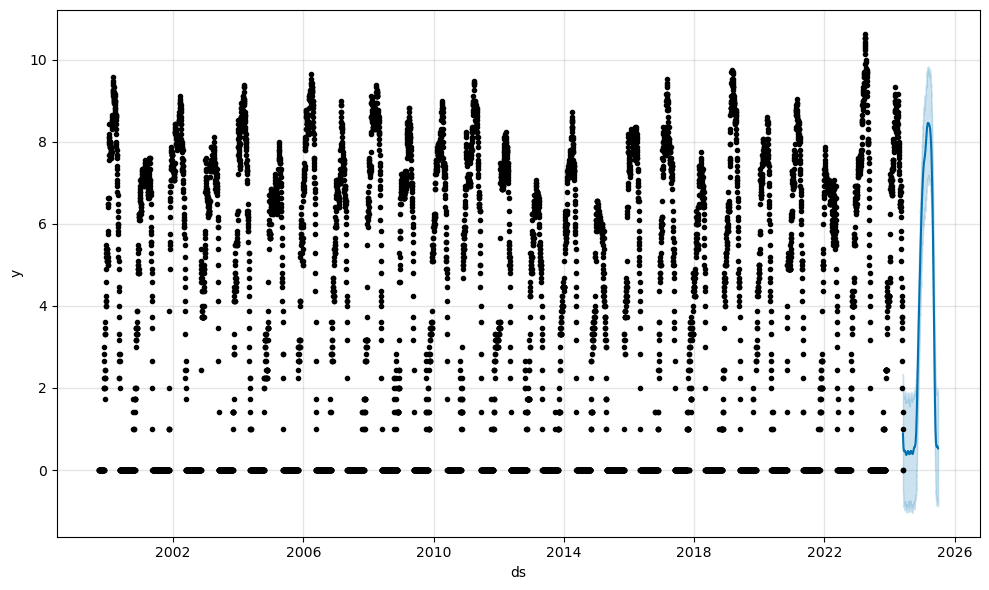

In [73]:
m = Prophet()
m.fit(prof_train)
prof_forecast = m.predict(prof_test)
plot = m.plot(prof_forecast)
plot.show()

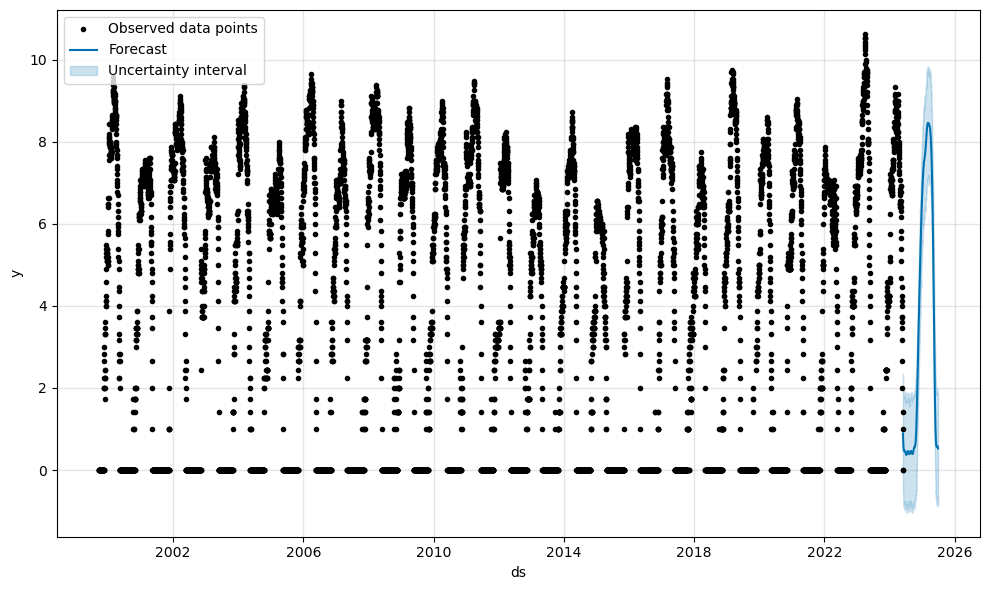

In [74]:
plot=m.plot(prof_forecast, include_legend=True, )
plot.show()

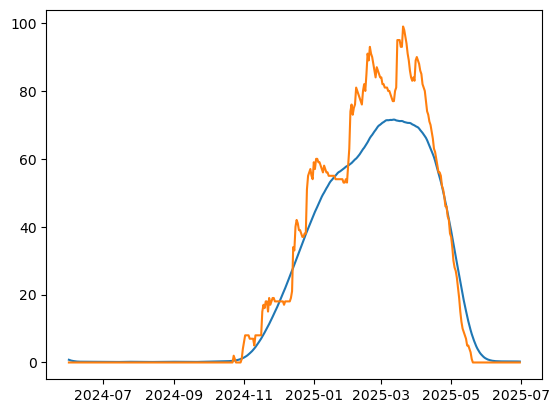

In [75]:
plt.plot(sd_test.index, prof_forecast['yhat']**2)
plt.plot(sd_test['ts'])

In [78]:
evaluate_performance(sd_test['ts_sqrt'], prof_forecast['yhat'], 'profet')

=== profet Performance ===
MSPE: 0.5763
MAE:  0.6398
MAPE: nan
PM:   0.0000
----------------------------------------
